## Implementing a Convolutional Neural Network for Classification

Sefine a convolutional neural network with a dense top ...

In [255]:
import deeplay as dl
import torch

cnn = dl.Sequential(
    dl.ConvolutionalNeuralNetwork(
        in_channels=1, hidden_channels=[2], out_channels=4,
        pool=torch.nn.MaxPool2d(kernel_size=2), out_activation=torch.nn.ReLU,
    ),
    dl.Layer(torch.nn.MaxPool2d, kernel_size=2),
    # dl.Layer(torch.nn.Flatten),
    dl.Layer(torch.nn.AdaptiveAvgPool2d, output_size=4),
    dl.MultiLayerPerceptron(
        in_features=4 * 16, hidden_features=[8], out_features=2,
        out_activation=torch.nn.Identity,
    ),
)

print(cnn)

Sequential(
  (0): ConvolutionalNeuralNetwork(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Layer[Conv2d](in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
      (1): Conv2dBlock(
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (layer): Layer[Conv2d](in_channels=2, out_channels=4, kernel_size=3, stride=1, padding=1)
        (activation): Layer[ReLU]()
      )
    )
  )
  (1): Layer[MaxPool2d](kernel_size=2)
  (2): Layer[AdaptiveAvgPool2d](output_size=4)
  (3): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Layer[Linear](in_features=64, out_features=8, bias=True)
        (activation): Layer[ReLU]()
      )
      (1): LinearBlock(
        (layer): Layer[Linear](in_features=8, out_features=2, bias=True)
        (activation): Layer[Identity]()
      )
    )
  )
)


... and compile it for a regression task.

In [256]:
from torchmetrics import MeanAbsoluteError as MAE

cnn_regressor_template = dl.Regressor(
    model=cnn, loss=torch.nn.MSELoss(), optimizer=dl.Adam(), metrics=[MAE()],
)
cnn_ann_regressor = cnn_regressor_template.create()

# print(cnn_ann_regressor)

## Loading data for Q3

In [257]:
import pickle as pkl
from torchvision.transforms import ToTensor
import numpy as np
import torch
import matplotlib.pyplot as plt

data = pkl.load(open('simple_particle_dataset.pkl', 'rb'))
image_size = 64

images = []
labels = []
for i in range(len(data["images"])):
    if data["labels"][i][0] != 0:
        images.append(data["images"][i])
        labels.append(data["labels"][i])


images = [img.astype(np.float32) for img in images]
images = list(map(ToTensor(), images))

# labels = [torch.tensor([(label[1]-image_size/2)/image_size, (label[2]-image_size/2)/image_size]).float() for label in labels]
labels = [torch.tensor([label[1], label[2]]).float() for label in labels]

dataset = list(zip(images, labels))



In [258]:
train, val, test = torch.utils.data.random_split(dataset, [0.7, 0.1, 0.2])

train_sim_dataloader = torch.utils.data.DataLoader(train, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val, batch_size=256, shuffle=False)
test_sim_dataloader = torch.utils.data.DataLoader(test, batch_size=256, shuffle=False)

## plot data

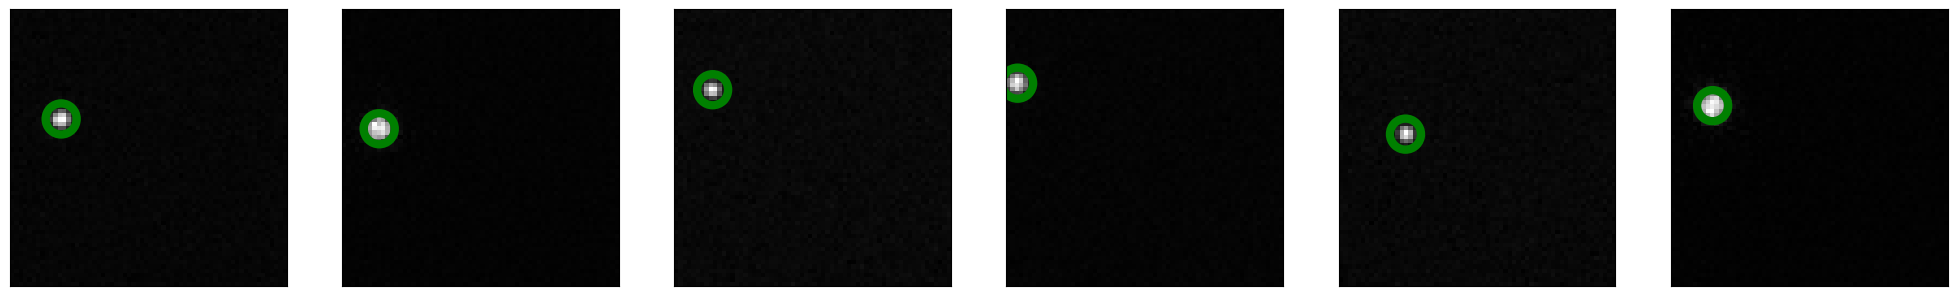

In [259]:
fig, axs = plt.subplots(1, 6, figsize=(25, 8))
for i, ax in enumerate(axs.flatten()):
    image, position = dataset[i]
    ax.imshow(np.squeeze(image), cmap="gray")
    ax.scatter(position[1], position[0], s=500, facecolors="none",
                edgecolors="g", linewidth=6)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## Training the Neural Network with Simulated Data

In [260]:
cnn_sim_regressor = cnn_regressor_template.create()
cnn_sim_trainer = dl.Trainer(max_epochs=200, accelerator="auto")
cnn_sim_trainer.fit(cnn_sim_regressor, train_sim_dataloader, val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │    634 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 634                                                                                              
Non-trainable params: 0                                                                                            
Total params: 634                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 199: 100%|██████████| 55/55 [00:00<00:00, 111.98it/s, v_num=173, train_loss_step=3.000, trainMeanAbsoluteError_step=1.390, val_loss_step=2.890, valMeanAbsoluteError_step=1.340, val_loss_epoch=2.770, valMeanAbsoluteError_epoch=1.290, train_loss_epoch=2.550, trainMeanAbsoluteError_epoch=1.230]


### plot trainin history

(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='Step'>,
        <Axes: title={'center': 'Meanabsoluteerror'}, xlabel='Step'>],
       dtype=object))

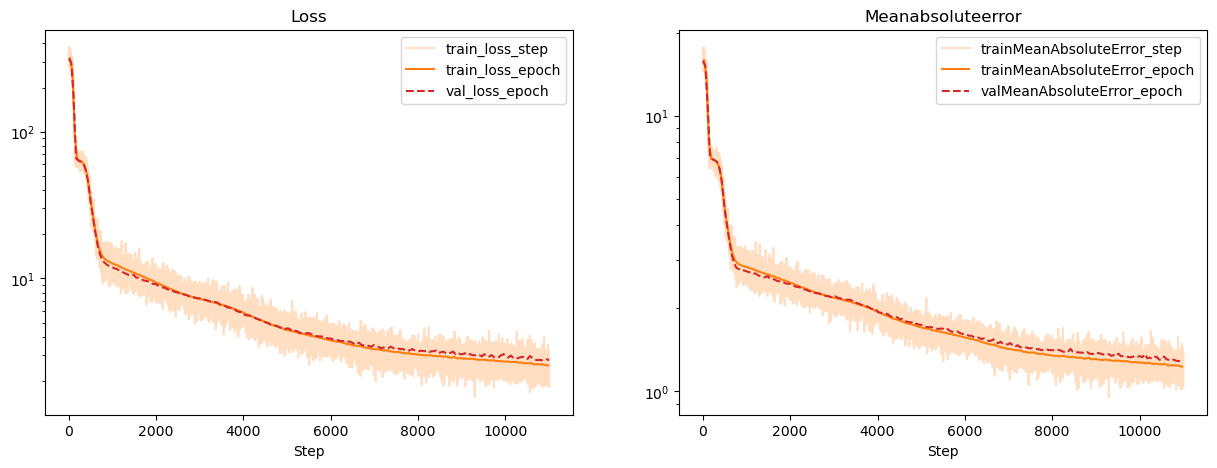

In [261]:
cnn_sim_trainer.history.plot()

### Testing the Trained Neural Network

In [262]:
test_sim_results = cnn_sim_trainer.test(cnn_sim_regressor, test_sim_dataloader)
MAE_sim = test_sim_results[0]["testMeanAbsoluteError_epoch"] #* image_size
print(f"Mean pixel error (MAE): {MAE_sim:.3f} pixels")

Testing DataLoader 0: 100%|██████████| 4/4 [00:00<00:00, 49.27it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMeanAbsoluteError_epoch │     1.2461585998535156      │
│       test_loss_epoch       │     2.5729594230651855      │
└─────────────────────────────┴─────────────────────────────┘

Mean pixel error (MAE): 1.246 pixels
